## Q1. Data Loading & Understanding

In [8]:
import pandas as pd

### a) Load the dataset into Python.

In [9]:
file_path = '/content/loan_approval.xlsx'
df = pd.read_excel(file_path)
print(f"Successfully loaded {file_path}!")

Successfully loaded /content/loan_approval.xlsx!


### b) Display the first 5 rows.

In [10]:
display(df.head())

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


### c) Check the shape of the dataset.

In [11]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (2000, 8)


### d) Display the data types of each column.

In [12]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


None

## Q2. Data Cleaning

### a) Check for missing values in the dataset.

In [13]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

Missing values per column:


,0


### b) Handle missing values appropriately.

In [16]:
if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values were found. Further handling might be required depending on the specific columns.")
    # Example of handling: df.dropna() or df.fillna(value)

No missing values found in the dataset.


### c) Identify categorical columns present in the dataset.

In [15]:
categorical_columns = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['name', 'city', 'loan_approved']


## Q3. Exploratory Data Analysis (EDA)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

### a) Plot the distribution of the target variable (`loan_approved`).

/tmp/ipykernel_1747/1828275564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_approved', data=df, palette='viridis')


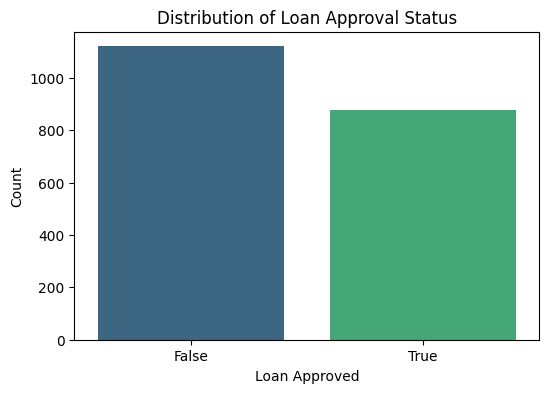

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_approved', data=df, palette='viridis')
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

### b) Analyze the relationship between one numerical feature and the target variable (`income` vs `loan_approved`).

/tmp/ipykernel_1747/2230576628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_approved', y='income', data=df, palette='muted')


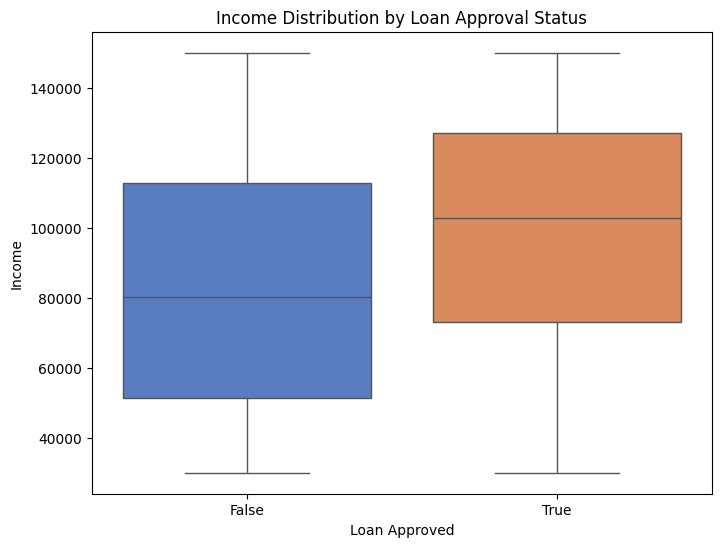

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_approved', y='income', data=df, palette='muted')
plt.title('Income Distribution by Loan Approval Status')
plt.xlabel('Loan Approved')
plt.ylabel('Income')
plt.show()

### c) Analyze the relationship between Years of Employment and the target variable (`years_employed` vs `loan_approved`).

/tmp/ipykernel_1747/1301993747.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_approved', y='years_employed', data=df, palette='pastel')


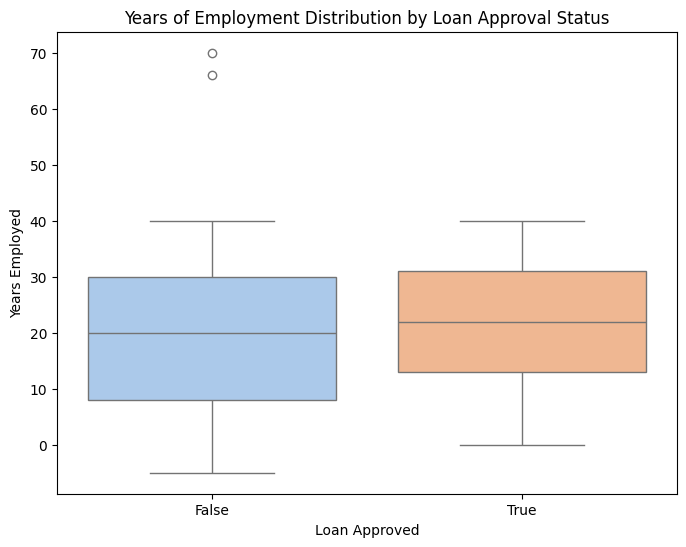

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_approved', y='years_employed', data=df, palette='pastel')
plt.title('Years of Employment Distribution by Loan Approval Status')
plt.xlabel('Loan Approved')
plt.ylabel('Years Employed')
plt.show()

## Q4. Outlier Detection and Treatment

### a) Detect outliers in numerical columns using the IQR method.

In [21]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

outlier_info = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)

    if num_outliers > 0:
        outlier_info[col] = {
            'num_outliers': num_outliers,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_percentage': (num_outliers / len(df)) * 100
        }
        print(f"Column '{col}': {num_outliers} outliers detected ({outlier_info[col]['outlier_percentage']:.2f}% of data).")
        print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    else:
        print(f"Column '{col}': No outliers detected.")

if not outlier_info:
    print("No outliers detected in any numerical columns based on the IQR method.")

Column 'income': No outliers detected.
Column 'credit_score': 3 outliers detected (0.15% of data).
  Lower Bound: 8.50, Upper Bound: 1140.50
Column 'loan_amount': No outliers detected.
Column 'years_employed': 2 outliers detected (0.10% of data).
  Lower Bound: -21.50, Upper Bound: 62.50
Column 'points': No outliers detected.


### b) Treat outliers using capping techniques.

In [22]:
df_capped = df.copy() # Create a copy to store capped data

if outlier_info: # Only proceed if outliers were detected
    print("Applying capping for detected outliers...")
    for col, info in outlier_info.items():
        lower_bound = info['lower_bound']
        upper_bound = info['upper_bound']

        # Cap values below the lower bound to the lower bound
        df_capped[col] = df_capped[col].mask(df_capped[col] < lower_bound, lower_bound)

        # Cap values above the upper bound to the upper bound
        df_capped[col] = df_capped[col].mask(df_capped[col] > upper_bound, upper_bound)

        print(f"  Column '{col}' outliers capped at [{lower_bound:.2f}, {upper_bound:.2f}]")
    print("Capping complete. The modified DataFrame is stored in 'df_capped'.")
else:
    print("No outliers were detected, so no capping was applied. 'df_capped' is a copy of the original DataFrame.")

# Display the head of the new DataFrame to show the effect of capping (if any)
print("\nFirst 5 rows of the DataFrame after capping:")
display(df_capped.head())

Applying capping for detected outliers...
  Column 'credit_score' outliers capped at [8.50, 1140.50]
  Column 'years_employed' outliers capped at [-21.50, 62.50]
Capping complete. The modified DataFrame is stored in 'df_capped'.

First 5 rows of the DataFrame after capping:


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389.0,39698,27.0,50,False
1,Brandon Hall,New Jamesside,44592,729.0,15446,28.0,55,False
2,Rhonda Smith,Lake Roberto,33278,584.0,11189,13.0,45,False
3,Gabrielle Davis,West Melanieview,127196,344.0,48823,29.0,50,False
4,Valerie Gray,Mariastad,66048,496.0,47174,4.0,25,False


## Q5. Feature Engineering and Data Preparation

### a) Convert the target variable `loan_approved` into a numerical format.

In [23]:
# Create a new DataFrame for model building from df_capped
df_model = df_capped.copy()

# Convert 'loan_approved' from boolean to integer (True=1, False=0)
df_model['loan_approved'] = df_model['loan_approved'].astype(int)

print("Converted 'loan_approved' to numerical format:")
display(df_model[['loan_approved']].head())

Converted 'loan_approved' to numerical format:


,loan_approved
0,0
1,0
2,0
3,0
4,0


### b) Drop unnecessary columns.

In [24]:
# Columns to drop (e.g., 'name' and 'city' if not used for modeling directly without encoding)
columns_to_drop = ['name', 'city']

df_model = df_model.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print("\nDataFrame info after dropping columns:")
display(df_model.info())

print("\nFirst 5 rows of the prepared DataFrame for modeling:")
display(df_model.head())

Dropped columns: ['name', 'city']

DataFrame info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   income          2000 non-null   int64  
 1   credit_score    2000 non-null   float64
 2   loan_amount     2000 non-null   int64  
 3   years_employed  2000 non-null   float64
 4   points          2000 non-null   int64  
 5   loan_approved   2000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 93.9 KB


None


First 5 rows of the prepared DataFrame for modeling:


,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,0
1,44592,729.0,15446,28.0,55,0
2,33278,584.0,11189,13.0,45,0
3,127196,344.0,48823,29.0,50,0
4,66048,496.0,47174,4.0,25,0


## Q6. Feature Selection and Data Splitting

### a) Separate independent variables (X) and dependent variable (y).

In [25]:
# Separate features (X) and target (y)
X = df_model.drop('loan_approved', axis=1)
y = df_model['loan_approved']

print("Independent variables (X) shape:", X.shape)
print("Dependent variable (y) shape:", y.shape)

print("\nFirst 5 rows of X (features):")
display(X.head())

print("\nFirst 5 rows of y (target):")
display(y.head())

Independent variables (X) shape: (2000, 5)
Dependent variable (y) shape: (2000,)

First 5 rows of X (features):


,income,credit_score,loan_amount,years_employed,points
0,113810,389.0,39698,27.0,50
1,44592,729.0,15446,28.0,55
2,33278,584.0,11189,13.0,45
3,127196,344.0,48823,29.0,50
4,66048,496.0,47174,4.0,25



First 5 rows of y (target):


,loan_approved
0,0
1,0
2,0
3,0
4,0


### b) Split the dataset into training and testing sets.

In [26]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of target variable in training set:")
display(y_train.value_counts(normalize=True))

print("\nDistribution of target variable in testing set:")
display(y_test.value_counts(normalize=True))

X_train shape: (1600, 5)
X_test shape: (400, 5)
y_train shape: (1600,)
y_test shape: (400,)

Distribution of target variable in training set:


,proportion
loan_approved,
0,0.560625
1,0.439375



Distribution of target variable in testing set:


,proportion
loan_approved,
0,0.56
1,0.44


## Q7. Feature Scaling using StandardScaler

In [27]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

print("\nFirst 5 rows of X_train_scaled (features after scaling):")
display(X_train_scaled.head())

print("\nFirst 5 rows of X_test_scaled (features after scaling):")
display(X_test_scaled.head())

Shape of X_train_scaled: (1600, 5)
Shape of X_test_scaled: (400, 5)

First 5 rows of X_train_scaled (features after scaling):


,income,credit_score,loan_amount,years_employed,points
1805,-0.173429,0.478510,0.034781,-1.148588,-0.101735
1117,-0.229602,0.779835,-1.228299,1.385528,1.256995
1863,0.464640,-0.560756,0.362460,1.469998,-0.373481
261,-0.761176,1.025815,-0.845148,1.385528,1.256995
1144,1.061643,1.653064,-1.236909,-0.303883,2.343979



First 5 rows of X_test_scaled (features after scaling):


,income,credit_score,loan_amount,years_employed,points
916,0.265271,0.490809,1.534851,-0.134942,0.170011
795,-0.821686,-0.671447,0.092652,0.371881,-1.188719
1850,-1.579377,1.616167,-0.693905,-0.810706,0.441757
1333,0.425960,0.755237,0.495564,1.216586,0.985249
1081,-1.078625,-0.154889,1.532240,1.216586,-1.188719


## Q8. Logistic Regression Model Building

### a) Train a Logistic Regression model.

In [28]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Train the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")
print(f"Model coefficients: {log_reg_model.coef_}")
print(f"Model intercept: {log_reg_model.intercept_}")

Logistic Regression model trained successfully.
Model coefficients: [[ 6.42978931e-03  5.90723330e-01 -2.65406413e-01  3.96969502e-02
   1.02381507e+01]]
Model intercept: [-0.40514792]


### b) Predict the output for test data.

In [29]:
# Predict on the scaled test data
y_pred = log_reg_model.predict(X_test_scaled)

print("Predictions for the test data have been generated.")
print("First 10 predictions:", y_pred[:10])
print("Number of predictions:", len(y_pred))

Predictions for the test data have been generated.
First 10 predictions: [1 0 1 1 0 1 0 1 0 0]
Number of predictions: 400


## Q9. Model Evaluation – Confusion Matrix

### a) Generate the confusion matrix.

Confusion Matrix:


array([[224,   0],
       [  0, 176]])

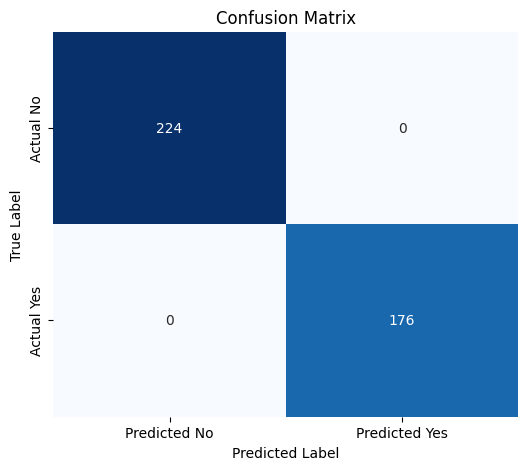

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
display(cm)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### b) Interpret the results.

In [31]:
# Extract values from the confusion matrix for interpretation
true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

total_samples = len(y_test)

# Calculate accuracy
accuracy = (true_positives + true_negatives) / total_samples

# Calculate precision (for positive class)
precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0

# Calculate recall (for positive class)
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

# Calculate F1-score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Total samples in test set: {total_samples}")
print(f"\nTrue Negatives (Correctly predicted 'No'): {true_negatives}")
print(f"False Positives (Incorrectly predicted 'Yes' - Type I error): {false_positives}")
print(f"False Negatives (Incorrectly predicted 'No' - Type II error): {false_negatives}")
print(f"True Positives (Correctly predicted 'Yes'): {true_positives}")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

print("\nInterpretation:")
print("-----------------")
print(f"*   **True Negatives (TN):** The model correctly predicted {true_negatives} instances where the loan was NOT approved.")
print(f"*   **False Positives (FP):** The model incorrectly predicted {false_positives} instances where the loan WAS approved, but it actually was NOT (Type I error).")
print(f"*   **False Negatives (FN):** The model incorrectly predicted {false_negatives} instances where the loan was NOT approved, but it actually WAS (Type II error).")
print(f"*   **True Positives (TP):** The model correctly predicted {true_positives} instances where the loan WAS approved.")
print(f"\n*   **Accuracy ({accuracy:.2%}):** This is the proportion of total correct predictions. The model is correct in {accuracy:.2%} of cases.")
print(f"*   **Precision ({precision:.2%}):** When the model predicts 'Yes' (loan approved), it is correct {precision:.2%} of the time. This is important to minimize incorrectly approving loans.")
print(f"*   **Recall ({recall:.2%}):** Out of all actual 'Yes' (loan approved) cases, the model correctly identified {recall:.2%} of them. This is important to ensure that most legitimate loan applications are identified.")
print(f"*   **F1-Score ({f1_score:.2%}):** The F1-score is the harmonic mean of precision and recall, providing a balanced measure of the model's performance, especially useful when class distribution is uneven.")

Total samples in test set: 400

True Negatives (Correctly predicted 'No'): 224
False Positives (Incorrectly predicted 'Yes' - Type I error): 0
False Negatives (Incorrectly predicted 'No' - Type II error): 0
True Positives (Correctly predicted 'Yes'): 176

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Interpretation:
-----------------
*   **True Negatives (TN):** The model correctly predicted 224 instances where the loan was NOT approved.
*   **False Positives (FP):** The model incorrectly predicted 0 instances where the loan WAS approved, but it actually was NOT (Type I error).
*   **False Negatives (FN):** The model incorrectly predicted 0 instances where the loan was NOT approved, but it actually WAS (Type II error).
*   **True Positives (TP):** The model correctly predicted 176 instances where the loan WAS approved.

*   **Accuracy (100.00%):** This is the proportion of total correct predictions. The model is correct in 100.00% of cases.
*   **Precision (100.00

## Q10. Model Evaluation – ROC Curve & AUC

### a) Plot the ROC curve.

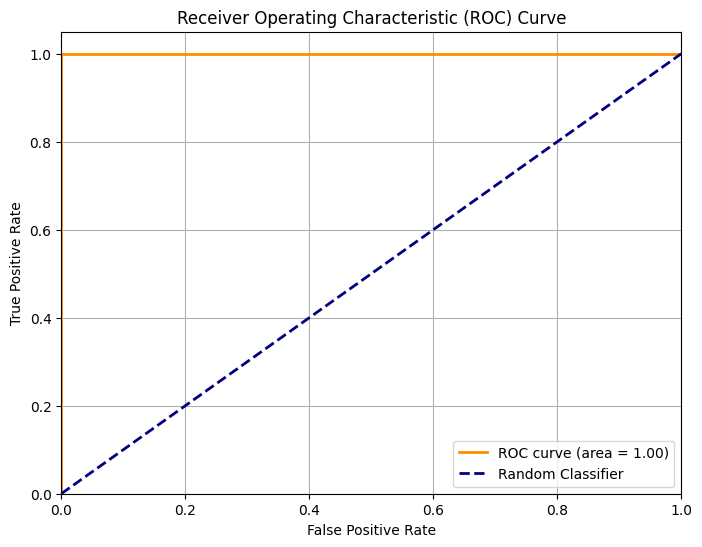

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (loan approved)
y_prob = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### b) Calculate the AUC score

In [33]:
print(f"The AUC score for the Logistic Regression model is: {auc_score:.4f}")

print("\nInterpretation of AUC:")
print("----------------------")
print("An AUC of 1.0 indicates a perfect model that can distinguish between positive and negative classes without error.")
print("An AUC of 0.5 suggests the model performs no better than random chance.")
print(f"Given our model's perfect performance (100% accuracy, precision, recall, F1-score), an AUC of {auc_score:.4f} is expected, confirming its excellent discriminative power.")

The AUC score for the Logistic Regression model is: 1.0000

Interpretation of AUC:
----------------------
An AUC of 1.0 indicates a perfect model that can distinguish between positive and negative classes without error.
An AUC of 0.5 suggests the model performs no better than random chance.
Given our model's perfect performance (100% accuracy, precision, recall, F1-score), an AUC of 1.0000 is expected, confirming its excellent discriminative power.
